<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B8%B0%EB%B0%98%ED%97%AC%EC%8A%A4%EC%BC%80%EC%96%B4%EA%B8%B0%EC%88%A0/netflix_eda_with_netflix_style.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('/content/netflix_titles.csv')

# 데이터 기본 정보 확인
print("--- 데이터 요약 ---")
display(df.info())

print("\n--- 결측치 확인 ---")
display(df.isnull().sum())

print("\n--- 데이터 상위 5행 ---")
display(df.head())

--- 데이터 요약 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


None


--- 결측치 확인 ---


,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0



--- 데이터 상위 5행 ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


/tmp/ipykernel_3449/2883191711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Reds_r')


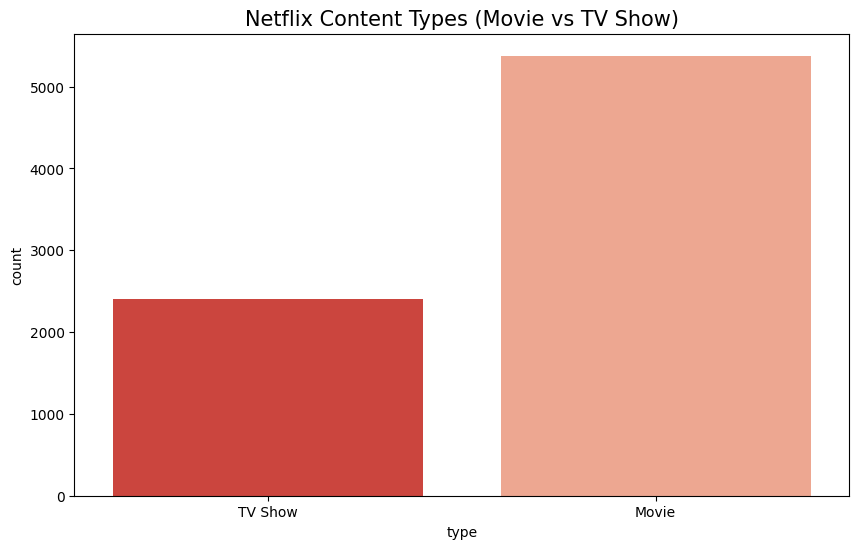

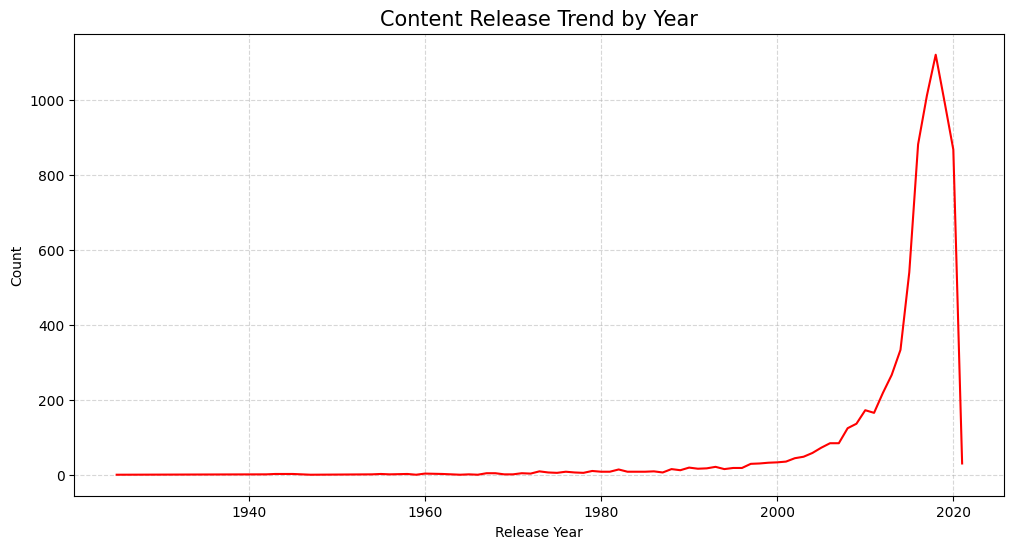

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 콘텐츠 타입(영화 vs TV 쇼) 분포 시각화
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df, palette='Reds_r')
plt.title('Netflix Content Types (Movie vs TV Show)', fontsize=15)
plt.show()

# 출시 연도별 콘텐츠 등록 트렌드
plt.figure(figsize=(12, 6))
release_year_counts = df['release_year'].value_counts().sort_index()
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values, color='red')
plt.title('Content Release Trend by Year', fontsize=15)
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<div style="color:red;
           display:fill;
           border-radius:5px;
           background-color:red;
           font-size:150%;
           font-family:Verdana;
           letter-spacing:0.5px">
<h1 style="text-align: center;
           padding: 10px;
           color:white;">
Netflix data analysis by Netflix Style !
</h1>
</div>

![](https://dl.img-news.com/dl/img/s3/dl/2020/09/netflix-logo.png)

# Intro!

### Hello kaggler. Are you enjoying Netflix usually?
### I enjoy Netflix too. I recently watched D.P. that famous korea Netflix series.
### It's so interesting :) If you know interesting movie in Netflix, share it plz!

<br><br>

### This time, I prepared the Netflix data EDA with Netflix style.
### I expect that you will like this style.
### It's my first Dark thema too.
### Then, Start now

![](https://newsimg.sedaily.com/2021/08/27/22QCO10SQF_2.jpg)

<div style="color:red;
           display:fill;
           border-radius:5px;
           background-color:red;
           font-size:150%;
           font-family:Verdana;
           letter-spacing:0.5px">
<h1 style="text-align: center;
           padding: 10px;
           color:white;">
Netflix's growth
</h1>
</div>

### First, I want to analysis Netflix's growth.
### Netflix is growing explosively.
### Look at these chart.

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import seaborn as sns
import pycountry
import geopandas
import datetime

import warnings
warnings.filterwarnings(action='ignore')

font = fm.FontProperties(fname='../input/anton-font/Anton-Regular.ttf')

data = pd.read_csv("../input/netflix-shows/netflix_titles.csv")
stock_price = pd.read_csv("../input/netflix-stock-price/NFLX  .csv")

stock_price['날짜'] = stock_price['날짜'].apply(lambda x: x.replace(" ","").replace("년","/").replace("월",""))
stock_price["날짜"] = pd.to_datetime(stock_price['날짜'])

stock_price= stock_price[['날짜',"종가"]]

stock_price.columns = ['date','price']

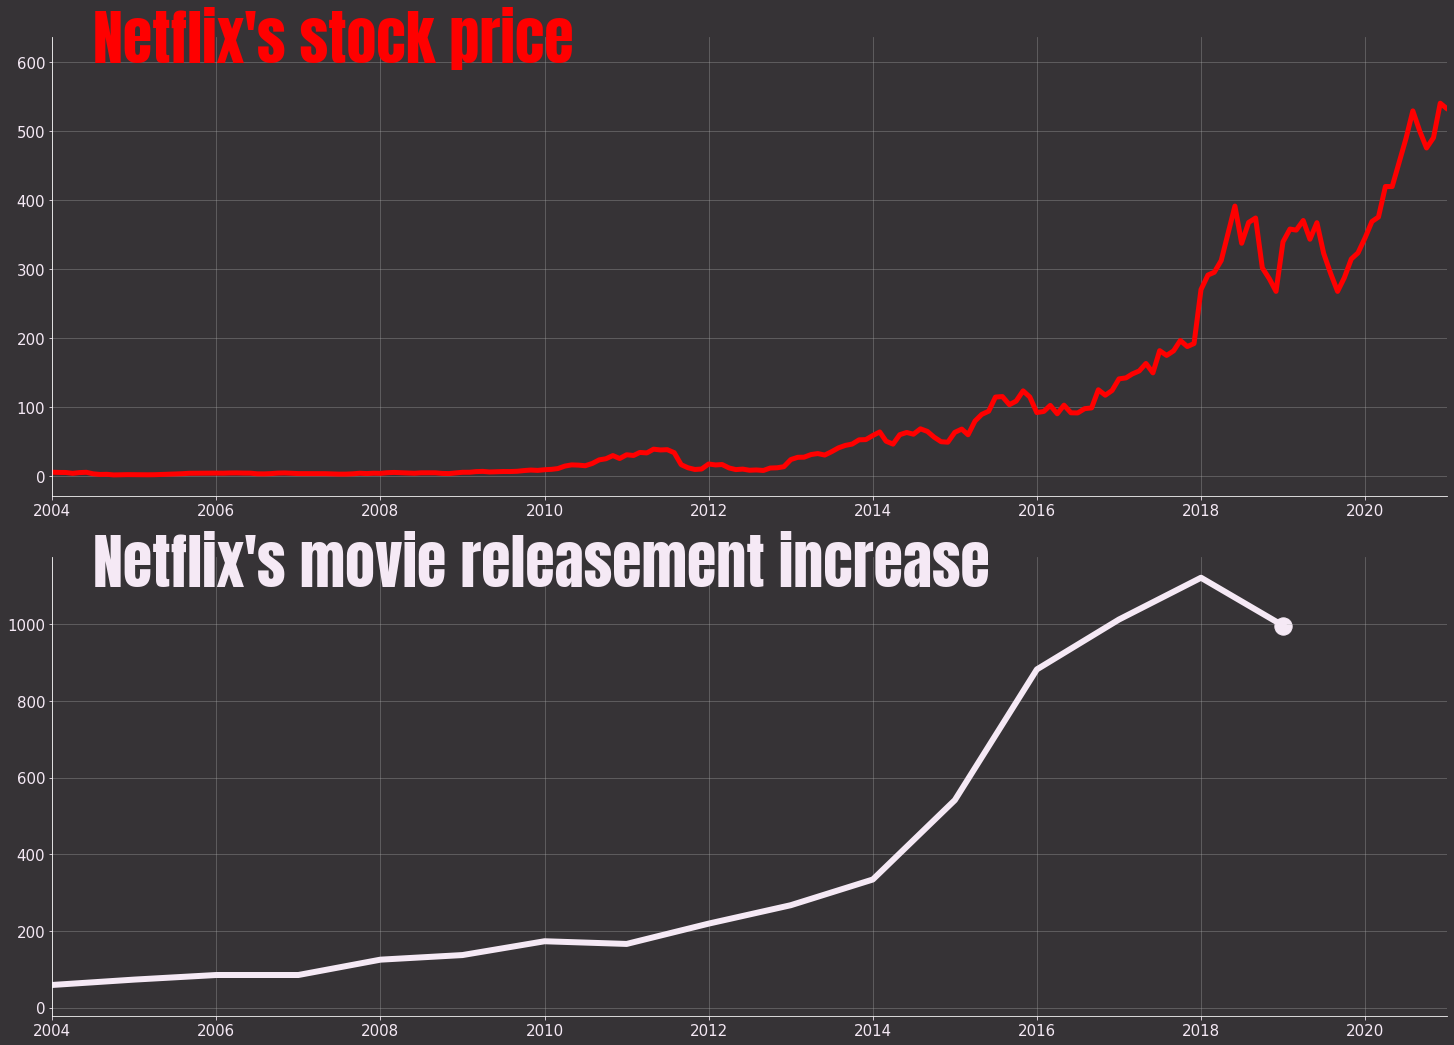

In [ ]:
fig, ax = plt.subplots(figsize=(25,18),facecolor="#363336")
ax.patch.set_facecolor('#363336')

spec = gridspec.GridSpec(ncols=1, nrows=19, figure=fig)
ax1 = fig.add_subplot(spec[:9, 0],facecolor="#363336")
ax2 = fig.add_subplot(spec[10:, 0],facecolor="#363336")
ax1.patch.set_facecolor('#363336')
sns.lineplot(x= stock_price['date'],y=stock_price['price'],lw=5, color='red',ax= ax1)
ax1.tick_params(axis='x', colors='#F5E9F5',labelsize=15)
ax1.tick_params(axis='y', colors='#F5E9F5',labelsize=15)
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.grid(True, alpha=0.4)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.text(s="Netflix's stock price", x= datetime.date(2004, 7, 1), y=600, font=font, fontsize=60,color = 'red')
ax1.set_xlim([datetime.date(2004, 1, 1), datetime.date(2021, 1, 1)])

a = dict(data['release_year'].value_counts())
a = sorted(a.items(), key = lambda x : x[0])
ax2.scatter(x= list(map(lambda x : x[0],a))[-3], y = list(map(lambda x : x[1],a))[-3], color="#F5E9F5", s= 300)
sns.lineplot(x= list(map(lambda x : x[0],a))[50:-2], y = list(map(lambda x : x[1],a))[50:-2],lw=6, color='#F5E9F5', ax=ax2)
ax2.tick_params(axis='x', colors='#F5E9F5',labelsize=15)
ax2.tick_params(axis='y', colors='#F5E9F5',labelsize=15)
ax2.spines['bottom'].set_color('white')
ax2.spines['left'].set_color('white')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.grid(True, alpha=0.4)
ax2.text(s="Netflix's movie releasement increase", x= 2004.5, y=1100, font=font, fontsize=60,color = '#F5E9F5')
ax2.set_xlim(2004,2021)

direct = ['right', 'left','bottom','top']
for di in direct:
    ax.spines[di].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [3]:
# 연도별 데이터 개수 확인 (최근 데이터 위주)
recent_counts = df['release_year'].value_counts().sort_index(ascending=False).head(10)
print("최근 연도별 콘텐츠 출시 수:")
print(recent_counts)

# 2021년 데이터가 실제로 존재하는지 확인
print(f"\n2021년 데이터 수: {len(df[df['release_year'] == 2021])}개")

최근 연도별 콘텐츠 출시 수:
release_year
2021      31
2020     868
2019     996
2018    1121
2017    1012
2016     882
2015     541
2014     334
2013     267
2012     219
Name: count, dtype: int64

2021년 데이터 수: 31개


### I prepared two chart to show Netflix's growth
### First is Netflix's stock price.
### Surely, Stock price doesn't explain that It's growth all.
<br>

### Then how about second chart.
### This is Netflix's movie releasement increase.
### I think, It mean that Netflix made an aggressive investment.
### Although, at 2020 discreased, because of Covid-19
### But, I think it will be increase again after Covid-19 and start of the release of the movie.
### Attention that, both stock price, and movie releasement increase have exploded since 2014.

<div style="color:red;
           display:fill;
           border-radius:5px;
           background-color:red;
           font-size:150%;
           font-family:Verdana;
           letter-spacing:0.5px">
<h1 style="text-align: center;
           padding: 10px;
           color:white;">
Netflix's worldwide popularity.
</h1>
</div>

### You can feel which country uses Netflix by looking at the next map.

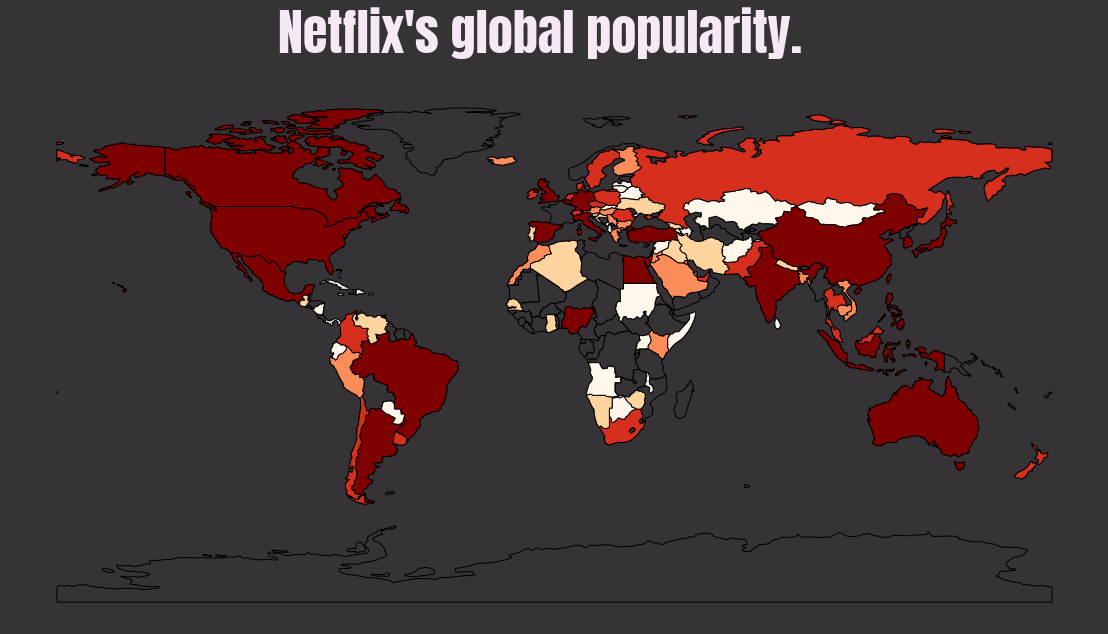

In [ ]:
country = data['country']
country = list(country)
total = []
for i in range(len(country)):
    total+=str(country[i]).split(", ")
country = Counter(total)
country = sorted(country.items(), key=lambda x : x[1],reverse=True)
name = list(map(lambda x : x[0],country))
count = list(map(lambda x : x[1],country))

country_name = name[0:3] + name[4:11]
country_name.reverse()
country_count = count[0:3] + count[4:11]
country_count.reverse()

country_data = pd.DataFrame(name,count).reset_index()
country_data.columns=['count', 'country']
country_data = country_data.drop(3)
country_data = country_data.reset_index(drop=True)
country_data['country'] = country_data['country'].apply(lambda x : x.replace(",",""))

not_have = {'South Korea' : 'KOR', 'West Germany' : 'DEU','Soviet Union':'SUN','East Germany':'DEU'}
for i in range(len(country_data['country'])):
    if country_data.loc[i, 'country'] in not_have.keys():
        country_data.loc[i, 'country'] = not_have[country_data.loc[i, 'country']]

country_data['country'] = country_data['country'].apply(lambda x : pycountry.countries.search_fuzzy(x)[0].alpha_3)
country_data = country_data.groupby('country').sum()
country_data = country_data.reset_index()

world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
world2 = world.merge(country_data,left_on ='iso_a3', right_on = 'country')

world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
world2 = world.merge(country_data,left_on ='iso_a3', right_on = 'country')

fig, ax = plt.subplots(figsize=(25,10),facecolor="#363336")
ax.patch.set_facecolor('#363336')
world.plot(ax=ax, color ="#363336",edgecolor='black')
world2.plot(column='count',ax=ax, cmap='OrRd', scheme='quantiles', edgecolor='black')
plt.text(s="Netflix's global popularity.", x=-100 ,y=110, font=font,color='#F5E9F5', va="center",ha="left",fontsize=50)
plt.axis('off')
plt.show()

### Netflix is enjoyed in most countries, without some of Africa.
### Especially, America and Ease Asia, Australia, India stand out.
### Now let's check the market share in more detail.

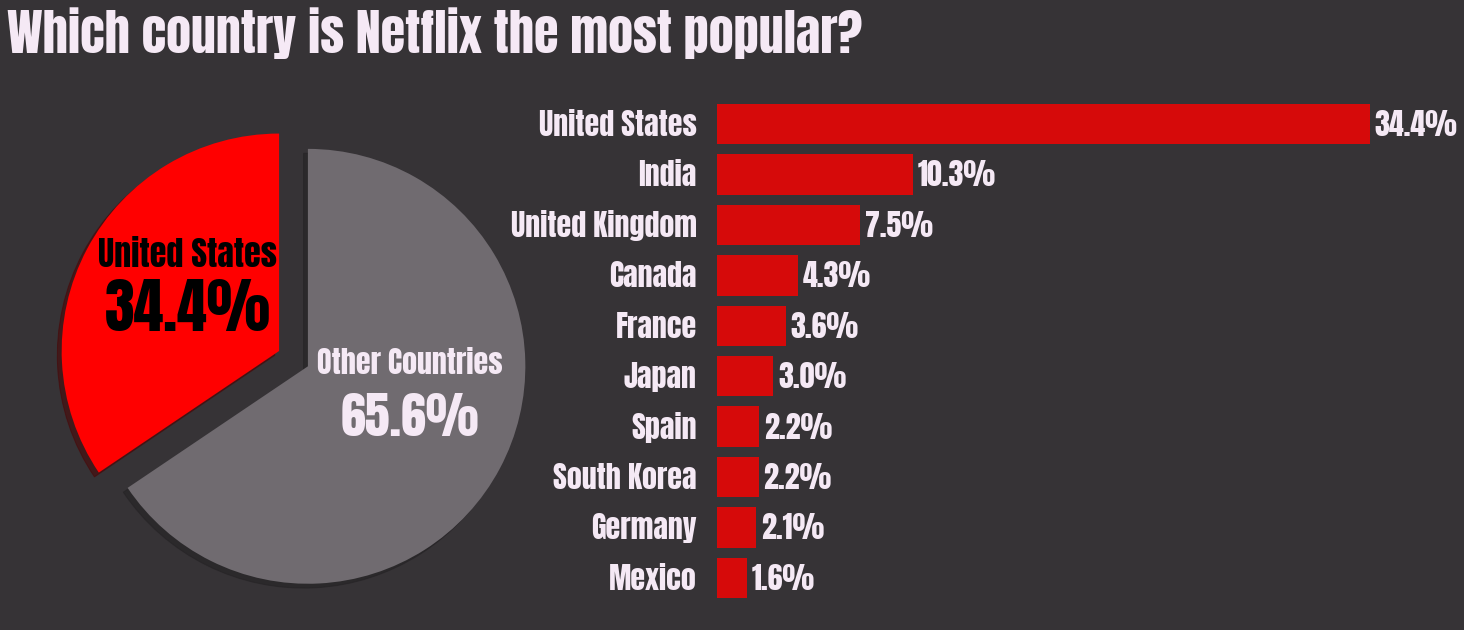

In [ ]:
labels = ['United States', 'Other Countries']
sizes = [count[0], sum(count[1:])]
explode = (0, 0.15)

fig, ax = plt.subplots(figsize=(25,10),facecolor="#363336")
ax.patch.set_facecolor('#363336')

spec = gridspec.GridSpec(ncols=10, nrows=1, figure=fig)
ax1 = fig.add_subplot(spec[0, :4],facecolor="#363336")
ax2 = fig.add_subplot(spec[0, 5:],facecolor="#363336")

ax1.pie(sizes, explode=explode, shadow=True, startangle=90, colors =['red','#706B70'])
ax1.text(s=labels[0],x=-0.42,y=0.45, font=font,fontsize=34,va='center',ha='center')
ax1.text(s=f"{round(sizes[0]/(sizes[0]+sizes[1]) * 100,1)}%",x=-0.42,y=0.2, font=font,fontsize=60,va='center',ha='center')
ax1.text(s=labels[1],x=0.6,y=-0.05, font=font,fontsize=30,color='#F5E9F5',va='center',ha='center')
ax1.text(s=f"{round(sizes[1]/(sizes[0]+sizes[1]) * 100,1)}%",x=0.6,y=-0.3, font=font,fontsize=50,color='#F5E9F5',va='center',ha='center')

ax2.barh(y=country_name, width=country_count, color = 'red', alpha=0.8)
for i in range(10):
    ax2.text(s=f"{country_name[i]}",x=-100,y=i,font=font,color='#F5E9F5', va="center",ha="right",fontsize=30)
    ax2.text(s=f"{round(country_count[i]/sum(count)*100,1)}%",x=country_count[i]+25,y=i,font=font,color='#F5E9F5', va="center",ha="left",fontsize=30)

ax2.axis("off")
ax.axis("off")
ax.text(s="Which country is Netflix the most popular?", x= 0,y=1.05, font=font,color='#F5E9F5',fontsize=50)
plt.show()

### As expected, the United States ranked first in market share.

### Surprisingly, it has more than a third of the market share.

### India and United Kingdom also showed high market share.

<div style="color:red;
           display:fill;
           border-radius:5px;
           background-color:red;
           font-size:150%;
           font-family:Verdana;
           letter-spacing:0.5px">
<h1 style="text-align: center;
           padding: 10px;
           color:white;">
Movie vs TV Show , What do you prefer?
</h1>
</div>

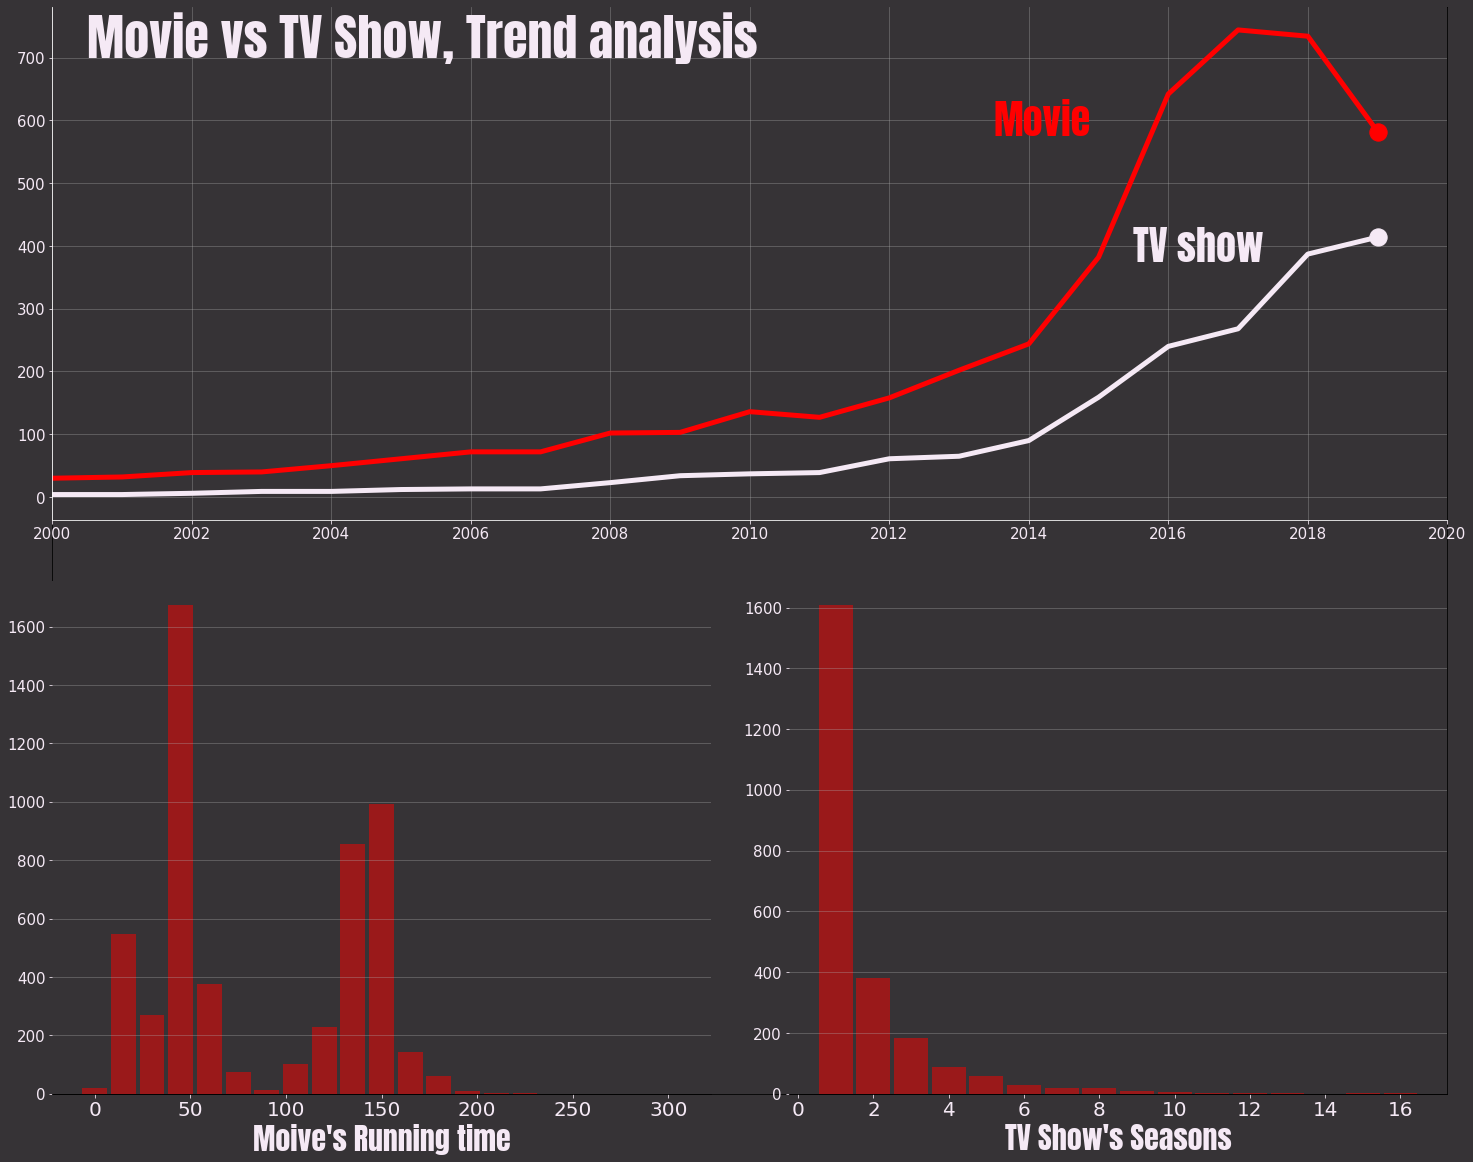

In [ ]:
type_data = data[['type','release_year']]
TV_show = type_data[type_data['type'] =='TV Show'].groupby('release_year')['type'].count()
Movie = type_data[type_data['type'] =='Movie'].groupby('release_year')['type'].count()

fig, ax = plt.subplots(figsize=(25,20),facecolor="#363336")
ax.patch.set_facecolor('#363336')

spec = gridspec.GridSpec(ncols=21, nrows=21, figure=fig)
ax1 = fig.add_subplot(spec[:10, :],facecolor="#363336")
ax2 = fig.add_subplot(spec[11:, :10],facecolor="#363336")
ax3 = fig.add_subplot(spec[11:, 11:],facecolor="#363336")


ax1.scatter(x= list(dict(TV_show).keys())[-3],y=list(dict(TV_show).values())[-3],s=300, color='#F5E9F5')
ax1.scatter(x= list(dict(Movie).keys())[-3],y=list(dict(Movie).values())[-3],s=300, color='red')
sns.lineplot(x= list(dict(TV_show).keys())[:-2],y=list(dict(TV_show).values())[:-2],lw=5, color='#F5E9F5',ax=ax1)
sns.lineplot(x= list(dict(Movie).keys())[:-2],y=list(dict(Movie).values())[:-2],lw=5, color='red',ax=ax1)
ax1.text(s="Movie", x=2013.5, y= 600,font=font,color='red', va="center",ha="left",fontsize=40)
ax1.text(s="TV show", x=2015.5, y= 400,font=font,color='#F5E9F5', va="center",ha="left",fontsize=40)
ax1.set_xticks(list(range(2000,2022,2)))
ax1.tick_params(axis='x', colors='#F5E9F5',labelsize=15)
ax1.tick_params(axis='y', colors='#F5E9F5',labelsize=15)
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xlim(2000,2020)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.grid(True, alpha=0.4)
ax1.text(s="Movie vs TV Show, Trend analysis", x= 2000.5,y=700, font=font,color='#F5E9F5',fontsize=50)


moive_running_time = data[data['type'] =='Movie']['duration'].apply(lambda x : x.split(" ")[0])
moive_running_time = pd.to_numeric(moive_running_time)
movie_running_time = pd.DataFrame(moive_running_time)
def make_range(x):
    return x//15

moive_running_time = moive_running_time.apply(make_range)
moive_running_time = pd.DataFrame(moive_running_time.value_counts())
moive_running_time['index'] = moive_running_time.reset_index()['index']*15

ax2.bar(x = moive_running_time['index'], height = moive_running_time['duration'],width=13,color ='red',alpha=0.5)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.set_xlabel("Moive's Running time", font=font, color='#F5E9F5', fontsize=30)
ax2.tick_params(axis='x', colors='#F5E9F5',labelsize=20)
ax2.set_ylabel("")
ax2.set_ylabel("")
ax2.grid(True, alpha=0.4,axis='y')
ax2.tick_params(axis='y', colors='#F5E9F5',labelsize=15)


TV_seasons = data[data['type'] =='TV Show']['duration'].apply(lambda x : x.split(" ")[0])
TV_seasons = pd.to_numeric(TV_seasons)
TV_seasons = pd.DataFrame(TV_seasons.value_counts())
ax3.bar(x = TV_seasons.index, height = TV_seasons.duration,width=0.9,color ='red',alpha=0.5)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_xlabel("TV Show's Seasons", font=font, color='#F5E9F5', fontsize=30)
ax3.tick_params(axis='x', colors='#F5E9F5',labelsize=20)
ax3.set_ylabel("")
ax3.set_ylabel("")
ax3.grid(True, alpha=0.4,axis='y')
ax3.tick_params(axis='y', colors='#F5E9F5',labelsize=15)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

### Both movies and TV shows remained on the rise, and Movie showed a big drop.
### Due to the Covid - 19, movie has not been released, so it seems to have shown a big decline.
### However, this may be a temporary phenomenon, so it remains to be seen whether Movie's trend will go downward.

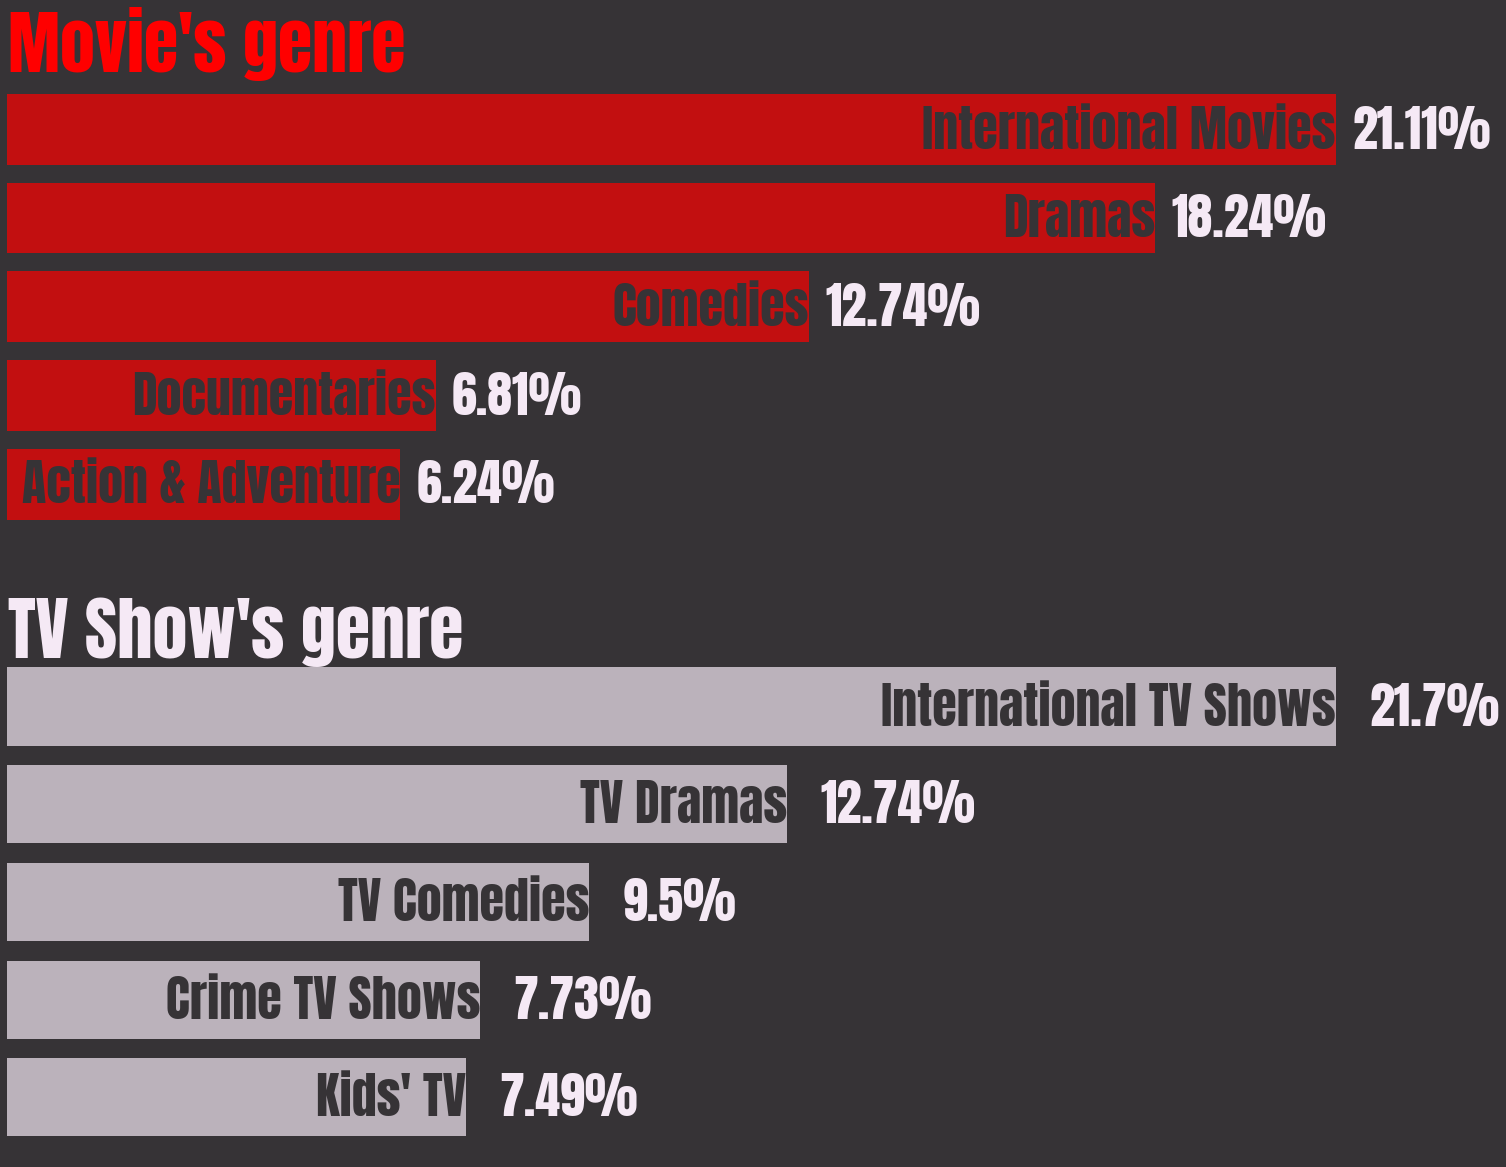

In [ ]:
movie_genre = []
TV_genre = []
for i in range(len(data)):

    genre =  data.loc[i,'listed_in'].split(", ")
    if data.loc[i,'type'] == 'TV Show':
        for j in genre:
            TV_genre.append(j)
    else:
        for j in genre:
            movie_genre.append(j)

movie_genre = Counter(movie_genre)
TV_genre = Counter(TV_genre)

movie_genre = pd.DataFrame(movie_genre.items())
TV_genre = pd.DataFrame(TV_genre.items())

movie_genre.columns = ['genre','movie_count']
TV_genre.columns = ['genre','tv_count']

movie_genre = movie_genre.sort_values(by= 'movie_count').reset_index(drop=True)
TV_genre = TV_genre.sort_values(by= 'tv_count').reset_index(drop=True)

movie_genre['per'] = round(movie_genre['movie_count'] / sum(movie_genre['movie_count']) * 100,2)
TV_genre['per'] = round(TV_genre['tv_count'] / sum(TV_genre['tv_count']) * 100,2)

fig, ax = plt.subplots(figsize=(25,20),facecolor="#363336")
ax.patch.set_facecolor('#363336')
spec = gridspec.GridSpec(ncols=21, nrows=23, figure=fig)
ax1 = fig.add_subplot(spec[:10, :],facecolor="#363336")
ax2 = fig.add_subplot(spec[12:,:],facecolor="#363336")

ax1.barh(y=movie_genre['genre'][-5:], width = movie_genre['movie_count'][-5:], color = 'red',alpha=0.7)
for i in range(15,20):
    ax1.text(s=movie_genre.loc[i,'genre'], x= movie_genre.loc[i,'movie_count'],y =i-15, va='center', ha='right',font=font, color = "#363336",fontsize=50)
    ax1.text(s=f"{movie_genre.loc[i,'per']}%", x= movie_genre.loc[i,'movie_count']+30,y =i-15, va='center', ha='left',font=font, color = '#F5E9F5',fontsize=50)
ax1.set_yticks([])
ax1.set_xticks([])

ax2.barh(y=TV_genre['genre'][:5], width = TV_genre['tv_count'][-5:],color = '#F5E9F5',alpha=0.7)
for i in range(17,22):
    ax2.text(s=TV_genre.loc[i,'genre'], x= TV_genre.loc[i,'tv_count'],y =i-17, va='center', ha='right',font=font, color = "#363336",fontsize=50)
    ax2.text(s=f"{TV_genre.loc[i,'per']}%", x= TV_genre.loc[i,'tv_count']+30,y =i-17, va='center', ha='left',font=font, color = '#F5E9F5',fontsize=50)
ax2.set_yticks([])
ax2.set_xticks([])

ax.set_xticks([])
ax.set_yticks([])

direct = ['right', 'left','bottom','top']
for di in direct:
    ax1.spines[di].set_visible(False)
    ax2.spines[di].set_visible(False)
    ax.spines[di].set_visible(False)

plt.text(s= "Movie's genre", x=1, y= 10.5, font=font, fontsize=70, color = 'red')
plt.text(s= "TV Show's genre", x=1, y= 4.5, font=font, fontsize=70, color = '#F5E9F5')

plt.show()

### Do you have favorite genre ?
### Compare the Movie's genre, and TV Show's genre.Their's 1st, 2nd, 3rd are same that International, Dramas, Comedies

<div style="color:red;
           display:fill;
           border-radius:5px;
           background-color:red;
           font-size:150%;
           font-family:Verdana;
           letter-spacing:0.5px">
<h1 style="text-align: center;
           padding: 10px;
           color:white;">
Who was the actor that appeared the most?
</h1>
</div>

In [ ]:
each_actor = []
countries_actor = list(data['country'].value_counts()[:15].index)
for countries in countries_actor:
    tmp = data[data['country'] == countries].copy()
    tmp = tmp.reset_index(drop=True)
    actors= []
    for i in range(len(tmp)):
        if tmp.loc[i,'cast'] =='NaN' or type(tmp.loc[i,'cast']) !=str:
            continue
        elif "," not in tmp.loc[i,'cast']:
            actors.append(tmp.loc[i,'cast'])
        else:
            for j in tmp.loc[i,'cast'].split(", "):
                actors.append(j)
    print(countries, " : ",sorted(Counter(actors).items(), key= lambda x :x[1],reverse=True)[0])
    each_actor.append(sorted(Counter(actors).items(), key= lambda x :x[1],reverse=True)[0][0])

countries_actor[0] = 'United States of America'

United States  :  ('Adam Sandler', 19)
India  :  ('Anupam Kher', 39)
United Kingdom  :  ('John Cleese', 10)
Japan  :  ('Takahiro Sakurai', 28)
South Korea  :  ('Kyeong-yeong Lee', 5)
Canada  :  ('Robb Wells', 14)
Spain  :  ('Mario Casas', 9)
France  :  ('Wille Lindberg', 5)
Egypt  :  ('Ahmed Helmy', 13)
Mexico  :  ('Sofía Niño de Rivera', 5)
Turkey  :  ('Demet Akbağ', 12)
Australia  :  ('Magda Szubanski', 5)
Taiwan  :  ('Amanda Chou', 6)
Brazil  :  ('Thati Lopes', 3)
Philippines  :  ('Kathryn Bernardo', 10)


### These are actors who appeared the most each country
### Now visulization at map!

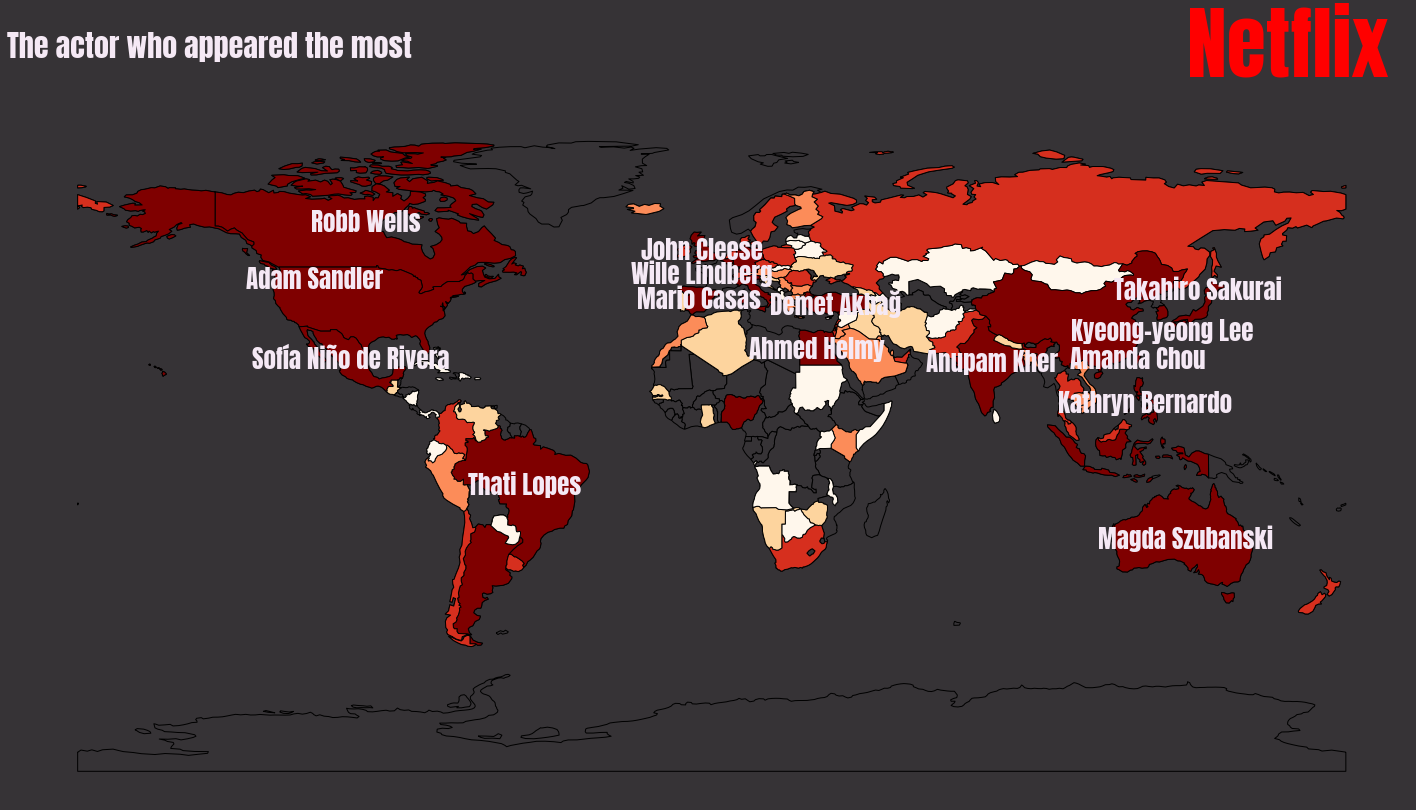

In [ ]:
fig, ax = plt.subplots(figsize=(25,15),facecolor="#363336")
ax.patch.set_facecolor('#363336')
world.plot(ax=ax, color ="#363336",edgecolor='black')
world2.plot(column='count',ax=ax, cmap='OrRd', scheme='quantiles', edgecolor='black')
plt.text(s="The actor who appeared the most", x=-200 ,y=110, font=font,color='#F5E9F5', va="center",ha="left",fontsize=30)
plt.text(s="Netflix", x=135 ,y=110, font=font,color='red', va="center",ha="left",fontsize=80)

plt.axis('off')

for i in range(15):
    x,y = str(world[world['name'] == countries_actor[i]]['geometry'].centroid).split('(')[1].split(')')[0].split(' ')
    x,y = float(x),float(y)
    if i == 3:
        y+=5
    if i == 4:
        y-=5
    if i == 7:
        y+=5
    plt.text(s=f"{each_actor[i]}", x=x ,y=y, font=font,color='#F5E9F5', va="center",ha="center",fontsize=25)

plt.show()

### I'm sorry I couldn't visualize more actors.
### Thanks to watch my work.
### I hope you like my visualization.